In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

chemin = r"\\frfs.sedes.inditex.grp\Rhome$\eliselc.SEDES\Descargas\dataset-festival.csv"

df = pd.read_csv(
    chemin,
    sep=";",
    encoding="utf-8",
    engine="python",
    on_bad_lines="skip"
)

In [7]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_").str.replace("'", "").str.replace("é", "e")
print(df.columns.tolist())

['\ufeffnom_du_festival', 'envergure_territoriale', 'region_principale_de_deroulement', 'departement_principal_de_deroulement', 'commune_principale_de_deroulement', 'code_postal_(de_la_commune_principale_de_deroulement)', 'code_insee_commune', 'code_insee_epci', 'libelle_epci', 'numero_de_voie', 'type_de_voie_(rue,_avenue,_boulevard,_etc.)', 'nom_de_la_voie', 'adresse_postale', 'complement_dadresse_(facultatif)', 'site_internet_du_festival', 'adresse_e-mail', 'decennie_de_creation_du_festival', 'annee_de_creation_du_festival', 'discipline_dominante', 'sous-categorie_spectacle_vivant', 'sous-categorie_musique', 'sous-categorie_musique_cnm', 'sous-categorie_cinema_et_audiovisuel', 'sous-categorie_arts_visuels_et_arts_numeriques', 'sous-categorie_livre_et_litterature', 'periode_principale_de_deroulement_du_festival', 'identifiant_agence_a', 'identifiant', 'geocodage_xy', 'identifiant_cnm']


In [9]:
print(df.head())
print(df.columns.tolist())
print(df.info())

                               ﻿nom_du_festival envergure_territoriale  \
0                    Des Planches et des Vaches                    NaN   
1                    Festival celte en Gevaudan              Régionale   
2  Festival International de Châteauroux - DARC         Interrégionale   
3                      Contre-plongées de l'été                    NaN   
4                     Festival des Filets Bleus                    NaN   

  region_principale_de_deroulement departement_principal_de_deroulement  \
0                        Normandie                             Calvados   
1             Auvergne-Rhône-Alpes                          Haute-Loire   
2              Centre-Val de Loire                                Indre   
3             Auvergne-Rhône-Alpes                          Puy-de-Dôme   
4                         Bretagne                            Finistère   

  commune_principale_de_deroulement  \
0            Hérouville-Saint-Clair   
1                         

In [10]:
df.dtypes

nom_du_festival                                          object
envergure_territoriale                                    object
region_principale_de_deroulement                          object
departement_principal_de_deroulement                      object
commune_principale_de_deroulement                         object
code_postal_(de_la_commune_principale_de_deroulement)     object
code_insee_commune                                        object
code_insee_epci                                           object
libelle_epci                                              object
numero_de_voie                                            object
type_de_voie_(rue,_avenue,_boulevard,_etc.)               object
nom_de_la_voie                                            object
adresse_postale                                           object
complement_dadresse_(facultatif)                          object
site_internet_du_festival                                 object
adresse_e-mail            

C:\Users\local_eliselc\Temp\ipykernel_24056\1935237737.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.values, y=counts.index, palette='viridis')


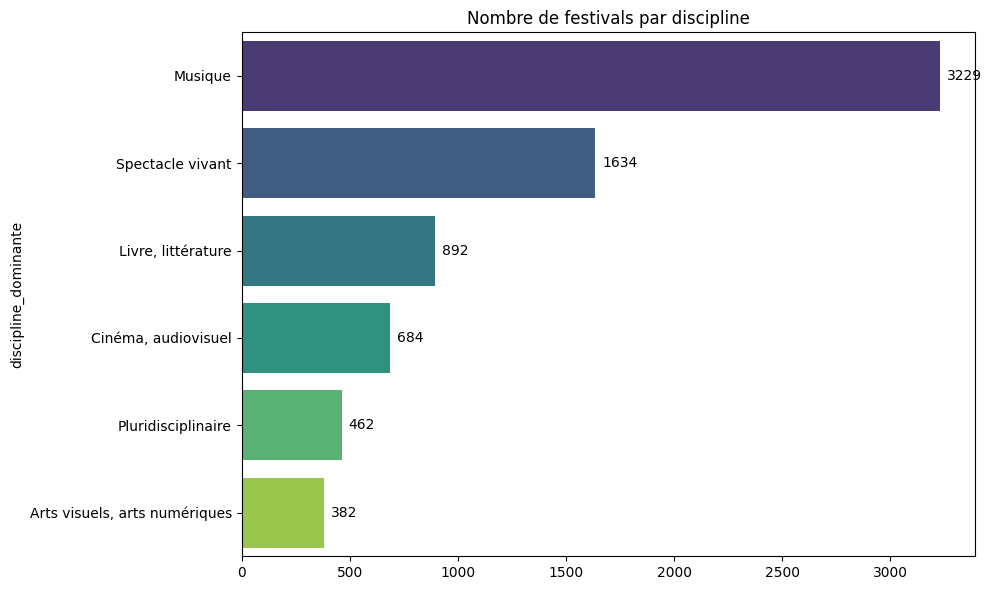

In [13]:
counts = df['discipline_dominante'].value_counts()

plt.figure(figsize=(10,6))
ax = sns.barplot(x=counts.values, y=counts.index, palette='viridis')

for bar in ax.patches:
    ax.annotate(
        f"{int(bar.get_width())}",
        (bar.get_width(), bar.get_y() + bar.get_height()/2),
        va='center',
        ha='left',
        xytext=(5,0),
        textcoords='offset points'
    )

plt.title("Nombre de festivals par discipline")
plt.tight_layout()
plt.show()

C:\Users\local_eliselc\Temp\ipykernel_24056\1107144429.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_regions.values, y=top_regions.index, palette='coolwarm')


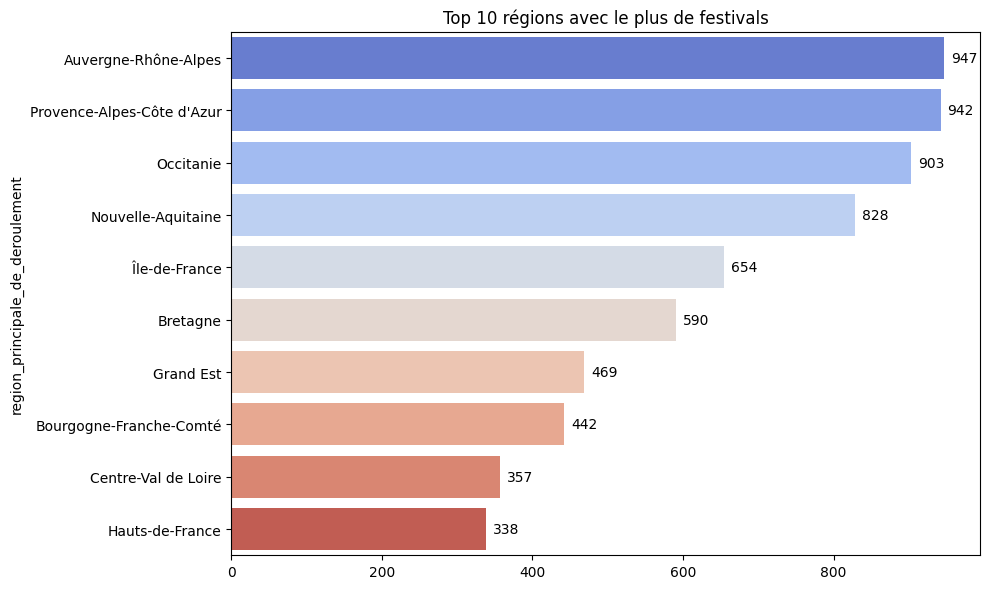

In [14]:
top_regions = df['region_principale_de_deroulement'].value_counts().head(10)

plt.figure(figsize=(10,6))
ax = sns.barplot(x=top_regions.values, y=top_regions.index, palette='coolwarm')

for bar in ax.patches:
    ax.annotate(
        f"{int(bar.get_width())}",
        (bar.get_width(), bar.get_y() + bar.get_height()/2),
        va='center',
        ha='left',
        xytext=(5,0),
        textcoords='offset points'
    )

plt.title("Top 10 régions avec le plus de festivals")
plt.tight_layout()
plt.show()

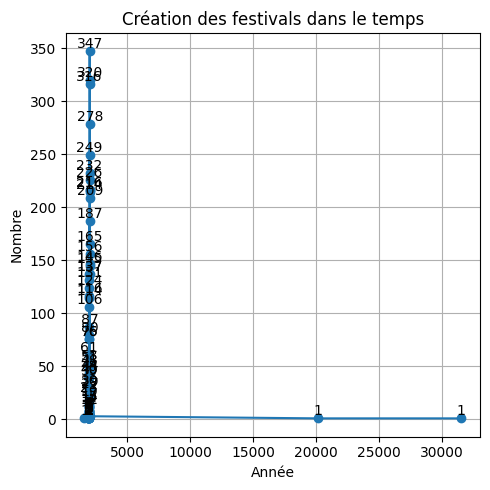

In [16]:
df['annee_de_creation_du_festival'] = pd.to_numeric(
    df['annee_de_creation_du_festival'], errors='coerce'
)

df_year = df.dropna(subset=['annee_de_creation_du_festival'])

counts = df_year['annee_de_creation_du_festival'].value_counts().sort_index()

plt.figure(figsize=(5,5))
plt.plot(counts.index, counts.values, marker='o')

for x, y in zip(counts.index, counts.values):
    plt.text(x, y, str(int(y)), ha='center', va='bottom')

plt.title("Création des festivals dans le temps")
plt.xlabel("Année")
plt.ylabel("Nombre")
plt.grid(True)
plt.tight_layout()
plt.show()

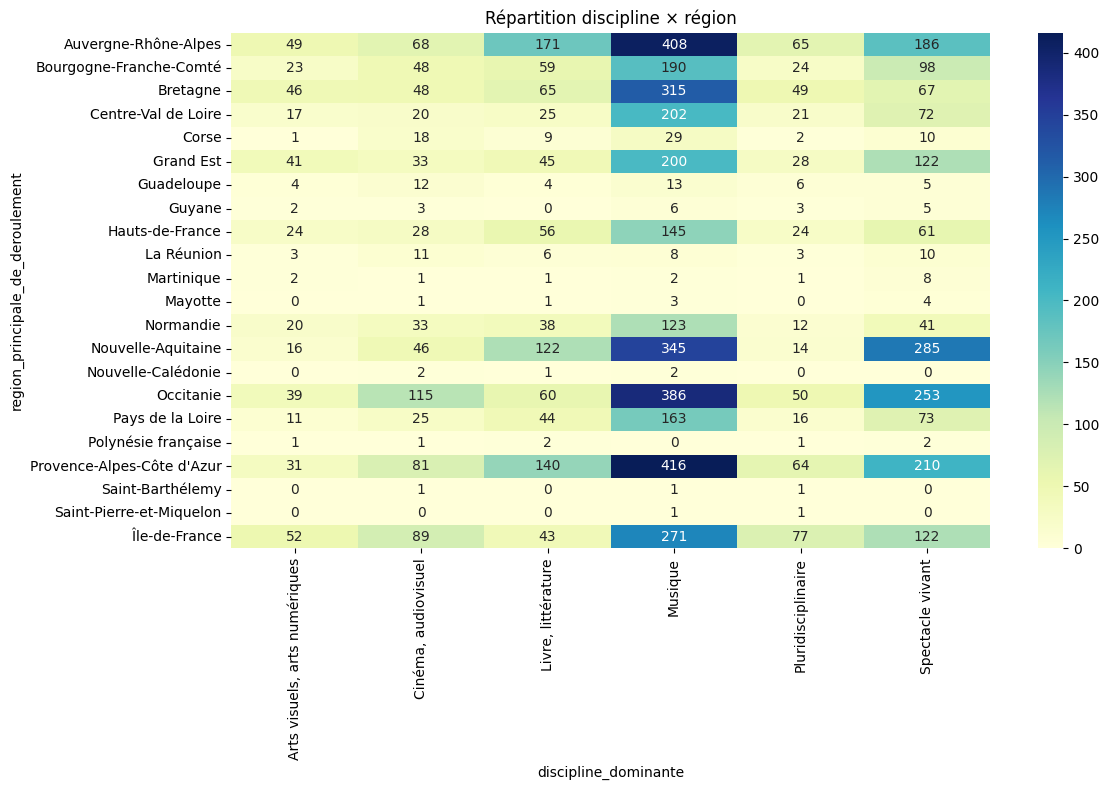

In [18]:
pivot = pd.crosstab(
    df['region_principale_de_deroulement'],
    df['discipline_dominante']
)

plt.figure(figsize=(12,8))
sns.heatmap(pivot, annot=True, fmt="d", cmap='YlGnBu')

plt.title("Répartition discipline × région")
plt.tight_layout()
plt.show()

KeyError: 'nom_du_festival'